# Calculating Dynamic Modulus $G(t)$

For the purposes of classifying/observing the viscoelastic properties of the bulk polymer, we calculate a time averaged dynamic modulus $\bar G(t)$

$$G(t) = \frac V {k_B T} \langle \sigma_{xy}(t)\sigma_{xy}(0)\rangle$$

$$\bar G(t) = \frac 1 t \int_0^t G(t')dt'$$

(Raffaeli and Ellenbroek)

For smoother curves with more sampling, we average over all possible perpendicular axes,

$$G(t) = \frac V {5 k_BT}\left[\langle\sigma_xy(t)\sigma_xy(0)\rangle+\langle\sigma_yz(t)\sigma_yz(0)\rangle+\langle\sigma_xz(t)\sigma_xz(0)\rangle\right]$$

There doesn't seem to be a autocorrelation function for $t=0$, only for small constant time differences, so we can do this in Python post-processing after we have collected pressure data from the LAMMPS simulation.

Pressure from LAMMPS is in LJ units.

As noted in the the `compute stress/atom` docs, "per-atom stress is the negative of the per-atom pressure tensor." So, we can simply use the negative $xy$ component of pressure as the $xy$ component of the stress tensor.

However, this then means that 

$$G(t) = \frac V {k_B T} \langle (-p_{xy}(t))(-p_{xy}(0))\rangle$$
$$G(t) = \frac V {k_B T} \langle p_{xy}(t)p_{xy}(0)\rangle$$

so we can simply replace the stress terms with pressure terms.


## $\bar G(t)$ function definition

In [ ]:
import numpy as np

def overline_G_func(pxy, t):
    kB = 1.0       # Boltzmann constant = 1 in LJ units
    T = 1.0        # temperature
    V = 40**3      # volume
    # TODO: use constants, currently just using autocorrelation

    auto_corr = np.correlate(pxy - np.mean(pxy), pxy - np.mean(pxy), mode='full')
    corr = auto_corr[auto_corr.size // 2:] / np.arange(len(pxy), 0, -1)

    # corr /= corr[0]  # normalize? not sure if needed

    time = t
    dt = time[1] - time[0]

    overline_G = np.cumsum(corr) * dt / time
    overline_G[0] = overline_G[1]  # avoid division by zero
    overline_G /= overline_G[0]  # normalize by G(0)
    
    return overline_G, time


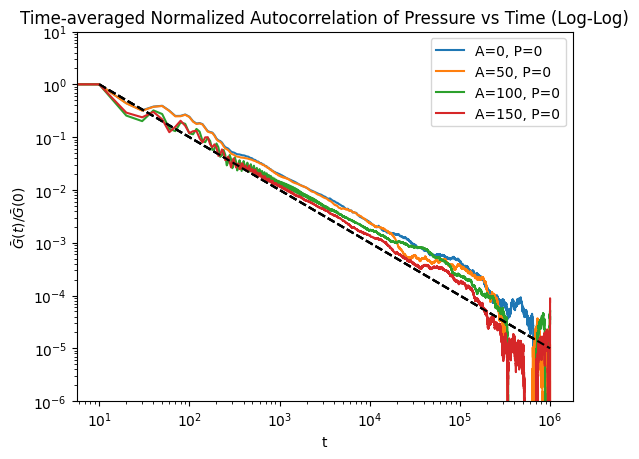

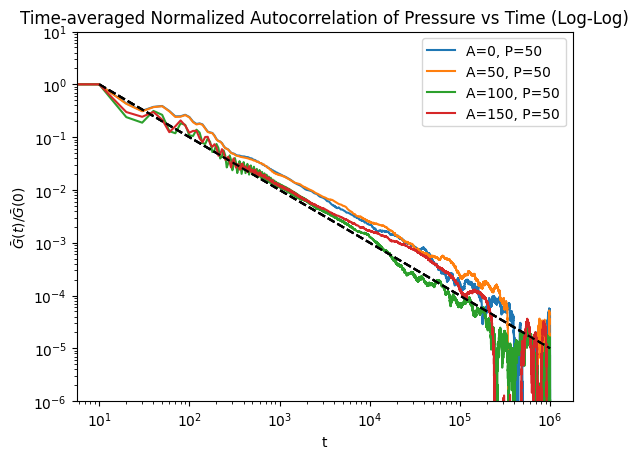

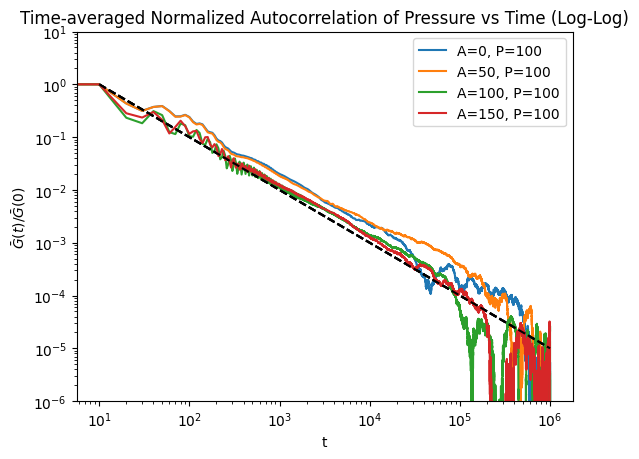

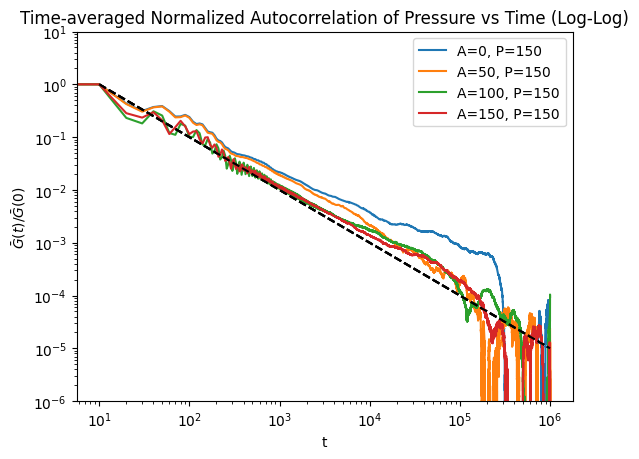

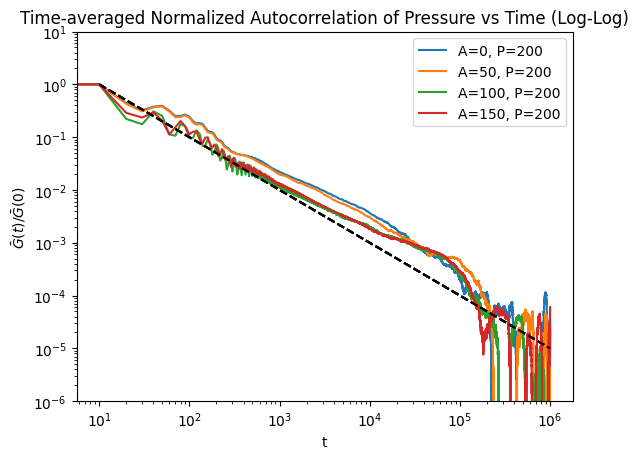

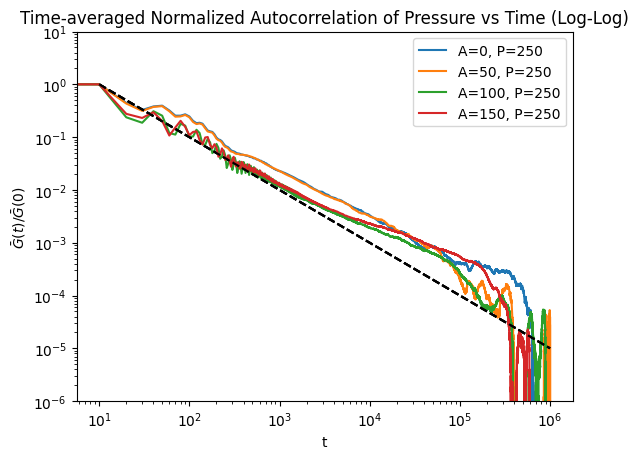

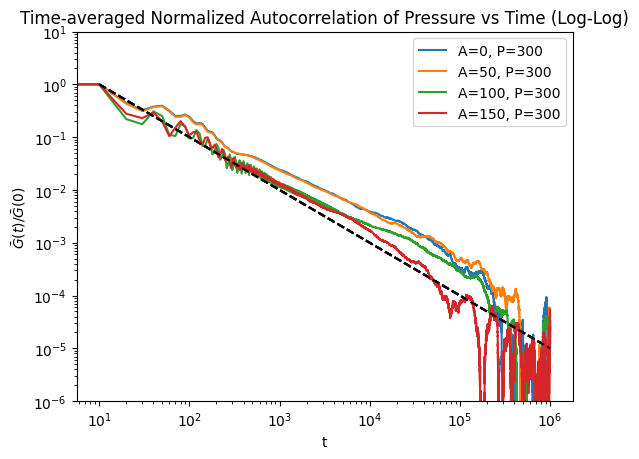

In [8]:
# time average of autocorrelation for different parameters
import matplotlib.pyplot as plt
import pandas as pd

P_values= [0, 50, 100, 150, 200, 250, 300]
patch_A_strengths=[0, 50, 100, 150]

for P in P_values:
    for patch_A_strength in patch_A_strengths:
        file = f"logs/press_{patch_A_strength}_{P}.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=2, names=['timestep', 'pxy'])
        # calculate time correlation of pxy
        pxy = data['pxy']
        t = data['timestep']
    
        overline_G, time = overline_G_func(pxy, t)

        # log log plot
        plt.loglog(time, overline_G, label=f'A={patch_A_strength}, P={P}')
        # add 1/t line for reference
        plt.loglog(time, 1/time * overline_G[1] * time[1], '--', color='black')
        plt.legend()
        plt.xlabel('t')
        plt.ylabel(r'$\bar G(t)/\bar G(0)$')
        plt.ylim(1e-6, 10)
        plt.title('Time-averaged Normalized Autocorrelation of Pressure vs Time (Log-Log)')
        plt.legend()
    plt.show()